# Lab 8 – Titanic Dataset Analysis with Seaborn

**Name:** Gaurav Vishal Doshi &nbsp;&nbsp; **Roll No:** 27

### Aim
- Use the inbuilt `titanic` dataset to find patterns using Seaborn.
- Plot a histogram showing distribution of ticket fare.

In [1]:
# Cell 1 – Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.options.display.max_columns = None
sns.set(style='whitegrid', palette='Set2')

In [2]:
# Cell 2 – Load Dataset
titanic = sns.load_dataset('titanic')
print('Dataset loaded successfully')
print('Shape:', titanic.shape)
print('Size :', titanic.size)
titanic.head()

Dataset loaded successfully
Shape: (891, 15)
Size : 13365


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Cell 3 – EDA: Info
print('Info:')
titanic.info()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [4]:
# Cell 4 – EDA: Describe & Unique Values
print('Describe (numeric columns):')
display(titanic.describe())

print('\nUnique values per column:')
print(titanic.nunique())

Describe (numeric columns):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Unique values per column:
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


In [5]:
# Cell 5 – EDA: Distribution Summaries
print('Survival distribution:')
print(titanic['survived'].value_counts())

print('\nClass distribution:')
print(titanic['pclass'].value_counts())

print('\nSex distribution:')
print(titanic['sex'].value_counts())

Survival distribution:
survived
0    549
1    342
Name: count, dtype: int64

Class distribution:
pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex distribution:
sex
male      577
female    314
Name: count, dtype: int64


In [6]:
# Cell 6 – Null Counts Before Removal
print('Null counts before removal:')
print(titanic.isnull().sum())

Null counts before removal:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [7]:
# Cell 7 – Remove Null Values
titanic_clean = titanic.dropna(subset=['survived', 'age', 'fare', 'embarked', 'embark_town']).reset_index(drop=True)

print('Shape after cleanup:', titanic_clean.shape)
print('\nNull counts after cleanup (key columns):')
print(titanic_clean[['survived', 'age', 'fare']].isnull().sum())

Shape after cleanup: (712, 15)

Null counts after cleanup (key columns):
survived    0
age         0
fare        0
dtype: int64


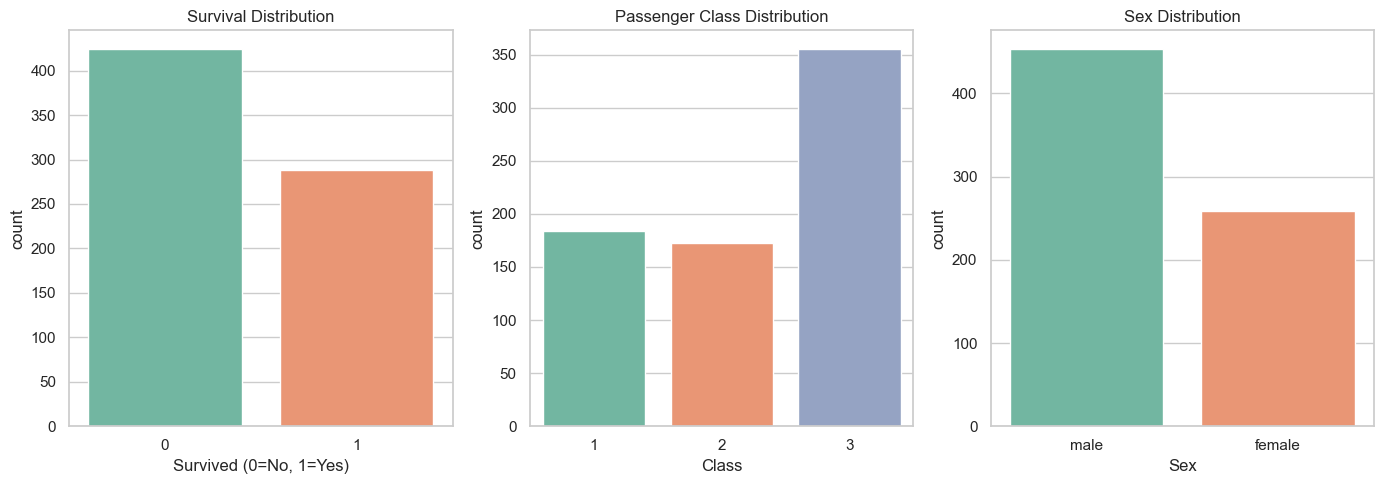

In [8]:
# Cell 8 – Visualisation: Count Plots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.countplot(data=titanic_clean, x='survived', hue='survived', palette='Set2',
              legend=False, ax=axes[0])
axes[0].set_title('Survival Distribution')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')

sns.countplot(data=titanic_clean, x='pclass', hue='pclass', palette='Set2',
              legend=False, ax=axes[1])
axes[1].set_title('Passenger Class Distribution')
axes[1].set_xlabel('Class')

sns.countplot(data=titanic_clean, x='sex', hue='sex', palette='Set2',
              legend=False, ax=axes[2])
axes[2].set_title('Sex Distribution')
axes[2].set_xlabel('Sex')

plt.tight_layout()
plt.show()

Shape before outlier cleanup: (712, 15)


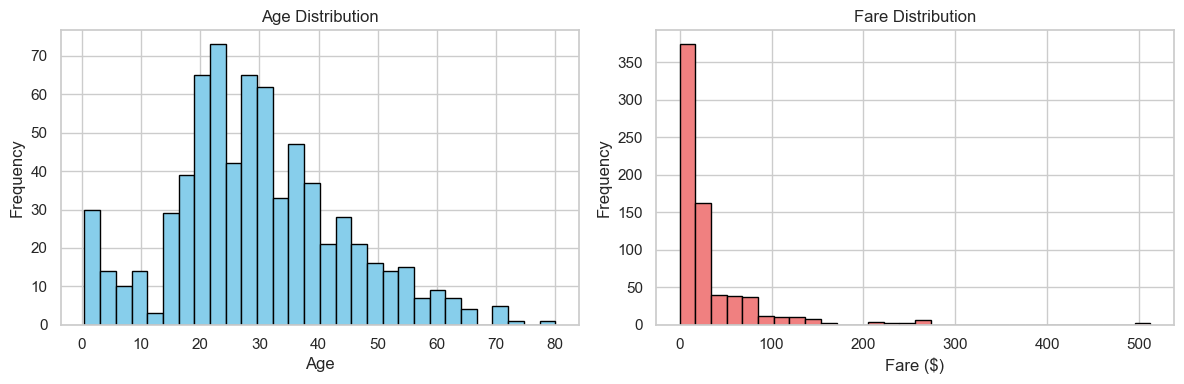

In [9]:
# Cell 9 – Age & Fare Distributions (Before Outlier Removal)
print('Shape before outlier cleanup:', titanic_clean.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(titanic_clean['age'],  bins=30, edgecolor='black', color='skyblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(titanic_clean['fare'], bins=30, edgecolor='black', color='lightcoral')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Shape after outlier cleanup: (610, 15)


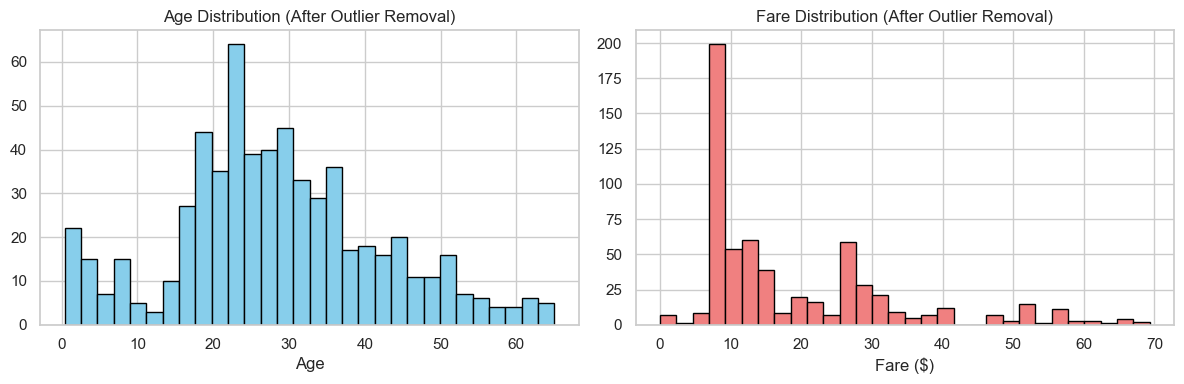

In [10]:
# Cell 10 – Outlier Detection & Removal (IQR on Age & Fare)
titanic_final = titanic_clean.copy()

for col in ['age', 'fare']:
    q1    = titanic_final[col].quantile(0.25)
    q3    = titanic_final[col].quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    titanic_final = titanic_final[
        (titanic_final[col] >= lower) & (titanic_final[col] <= upper)
    ]

titanic_final = titanic_final.reset_index(drop=True)
print('Shape after outlier cleanup:', titanic_final.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(titanic_final['age'],  bins=30, edgecolor='black', color='skyblue')
axes[0].set_title('Age Distribution (After Outlier Removal)')
axes[0].set_xlabel('Age')
axes[1].hist(titanic_final['fare'], bins=30, edgecolor='black', color='lightcoral')
axes[1].set_title('Fare Distribution (After Outlier Removal)')
axes[1].set_xlabel('Fare ($)')
plt.tight_layout()
plt.show()

In [11]:
# Cell 11 – Label Encoding (Sex & Class)
le_sex = LabelEncoder()
titanic_final['sex_num'] = le_sex.fit_transform(titanic_final['sex'])
print('Sex mapping:',   dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

le_class = LabelEncoder()
titanic_final['class_num'] = le_class.fit_transform(titanic_final['pclass'].astype(str))
print('Class mapping:', dict(zip(le_class.classes_, le_class.transform(le_class.classes_))))

titanic_final.head()

Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}
Class mapping: {'1': np.int64(0), '2': np.int64(1), '3': np.int64(2)}


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_num,class_num
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1,2
1,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,2
2,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,0
3,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,2
4,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,1,0


TASK 1: Finding Patterns in Titanic Data


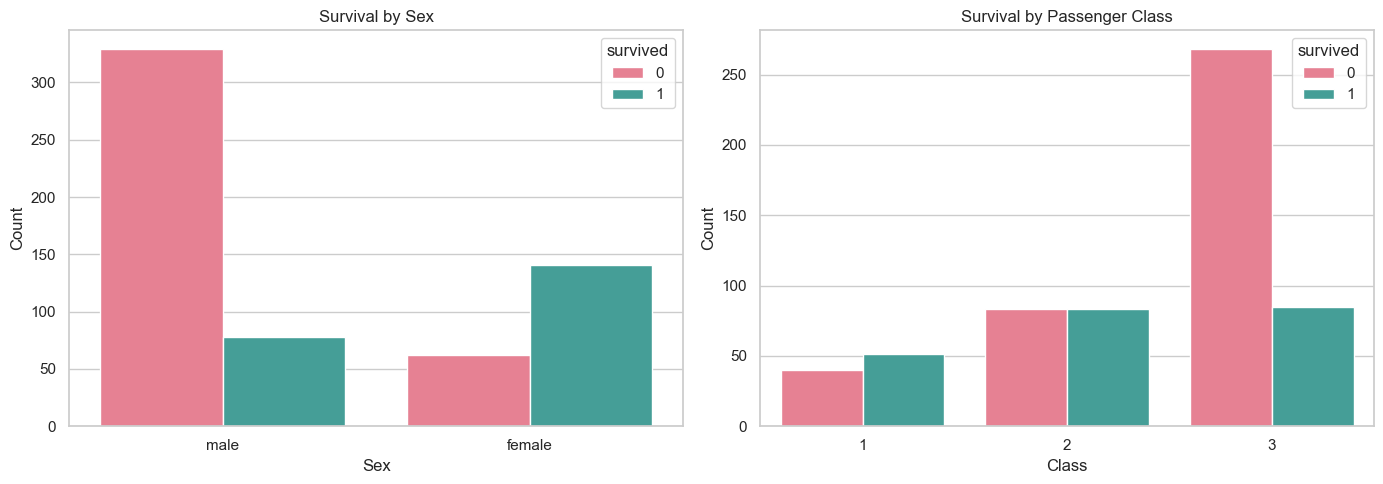


Survival Rate by Sex:
        sum  count      mean
sex                         
female  141    203  0.694581
male     78    407  0.191646

Survival Rate by Class:
        sum  count      mean
pclass                      
1        51     91  0.560440
2        83    166  0.500000
3        85    353  0.240793


In [12]:
# Cell 12 – Task 1: Patterns – Survival by Sex and Class
print('TASK 1: Finding Patterns in Titanic Data')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=titanic_final, x='sex',    hue='survived', palette='husl', ax=axes[0])
axes[0].set_title('Survival by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=titanic_final, x='pclass', hue='survived', palette='husl', ax=axes[1])
axes[1].set_title('Survival by Passenger Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('\nSurvival Rate by Sex:')
print(titanic_final.groupby('sex')['survived'].agg(['sum', 'count', 'mean']))

print('\nSurvival Rate by Class:')
print(titanic_final.groupby('pclass')['survived'].agg(['sum', 'count', 'mean']))

C:\Users\GAJENDRA\AppData\Local\Temp\ipykernel_192\2622101461.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic_final, x='survived', y='age',  palette='Set2', ax=axes[0])
C:\Users\GAJENDRA\AppData\Local\Temp\ipykernel_192\2622101461.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic_final, x='survived', y='fare', palette='Set2', ax=axes[1])


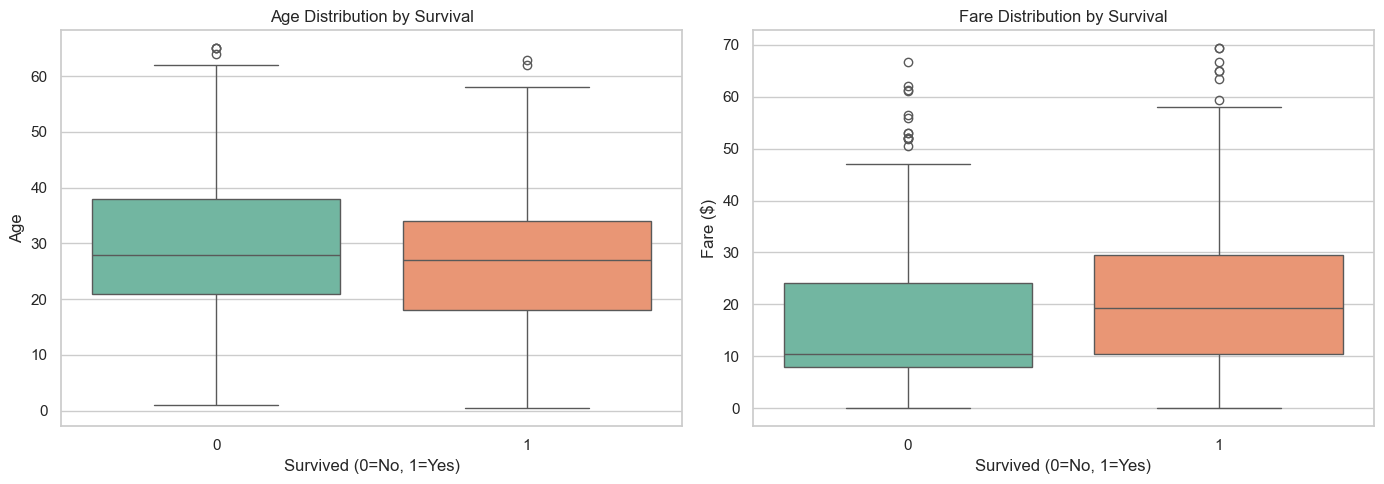

In [13]:
# Cell 13 – Age & Fare vs Survival (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=titanic_final, x='survived', y='age',  palette='Set2', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')
axes[0].set_ylabel('Age')

sns.boxplot(data=titanic_final, x='survived', y='fare', palette='Set2', ax=axes[1])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1].set_ylabel('Fare ($)')

plt.tight_layout()
plt.show()

Correlation with Survival:
survived    1.000000
fare        0.238268
parch       0.095204
sibsp      -0.028801
age        -0.129342
pclass     -0.278442
Name: survived, dtype: float64


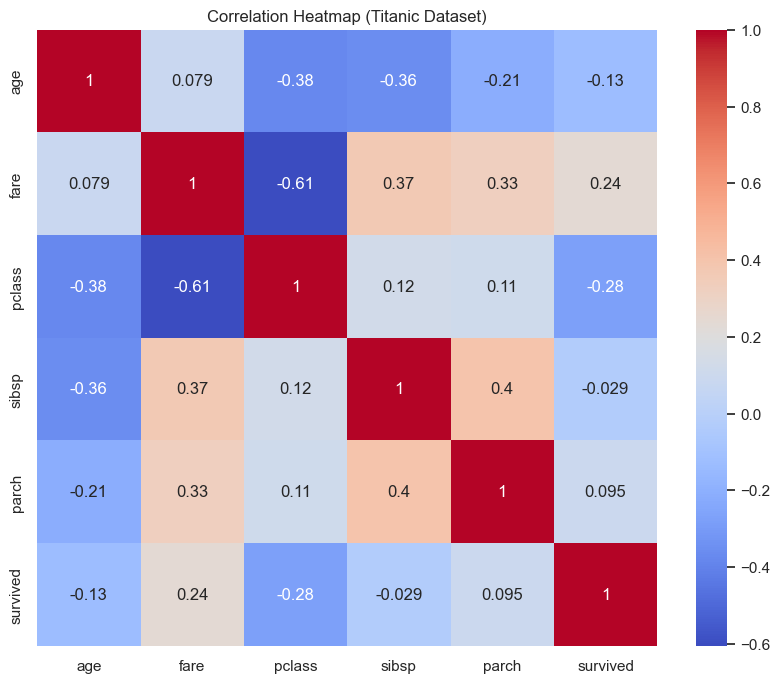

In [14]:
# Cell 14 – Correlation Heatmap
numeric_cols = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived']

print('Correlation with Survival:')
print(titanic_final[numeric_cols].corr()['survived'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(titanic_final[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Titanic Dataset)')
plt.show()

TASK 2: Fare Price Distribution


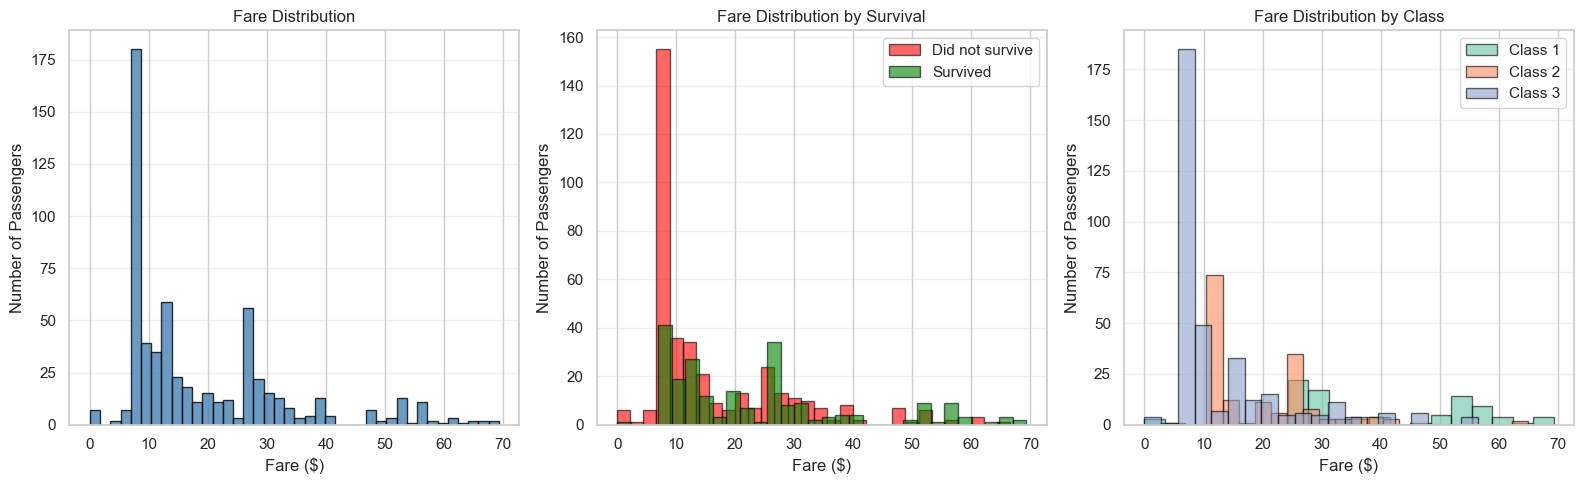


Fare Statistics by Class:
        count       mean        std   min     25%      50%      75%      max
pclass                                                                      
1        91.0  39.360991  15.980625   0.0  26.550  34.0208  53.1000  69.3000
2       166.0  20.036622   9.783995  10.5  13.000  14.7500  26.0000  65.0000
3       353.0  13.260409  10.063168   0.0   7.775   8.0500  15.7417  56.4958


In [15]:
# Cell 15 – Task 2: Fare Histogram (3 Views)
print('TASK 2: Fare Price Distribution')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Basic fare histogram
axes[0].hist(titanic_final['fare'], bins=40, edgecolor='black',
             color='steelblue', alpha=0.8)
axes[0].set_title('Fare Distribution')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Number of Passengers')
axes[0].grid(axis='y', alpha=0.3)

# By survival
survived_fare     = titanic_final[titanic_final['survived'] == 1]['fare']
not_survived_fare = titanic_final[titanic_final['survived'] == 0]['fare']
axes[1].hist(not_survived_fare, bins=30, alpha=0.6, label='Did not survive',
             color='red',   edgecolor='black')
axes[1].hist(survived_fare,     bins=30, alpha=0.6, label='Survived',
             color='green', edgecolor='black')
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlabel('Fare ($)')
axes[1].set_ylabel('Number of Passengers')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# By passenger class
for pclass in sorted(titanic_final['pclass'].unique()):
    axes[2].hist(titanic_final[titanic_final['pclass'] == pclass]['fare'],
                 bins=20, alpha=0.6, label=f'Class {int(pclass)}', edgecolor='black')
axes[2].set_title('Fare Distribution by Class')
axes[2].set_xlabel('Fare ($)')
axes[2].set_ylabel('Number of Passengers')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nFare Statistics by Class:')
print(titanic_final.groupby('pclass')['fare'].describe())